# EEG Frequency Band Analysis: Alzheimer's Disease vs Healthy Controls

This notebook transforms raw EEG signals into quantitative frequency-domain features relevant to Alzheimer's Disease detection.

**Pipeline:**
1. Load the raw EEG dataset (`X_raw`, `y_labels`)
2. Compute **Power Spectral Density (PSD)** using the **Welch method** (via `scipy.signal.welch`)
3. Extract average power in four clinically-relevant frequency bands:
   - **Delta** (1–4 Hz)
   - **Theta** (4–8 Hz)
   - **Alpha** (8–13 Hz)
   - **Beta** (13–30 Hz)
4. Build a per-channel, per-subject summary table
5. Compare band power between **AD** and **Healthy Control (HC)** groups

---
**Dataset**: Largest Alzheimer EEG Dataset (Kaggle)  
**Sampling Rate**: 128 Hz  
**Channels**: 19 (10-20 system)  
**Labels**: `0.0` = Healthy Control, `1.0` = Alzheimer's Disease

## 1. Imports & Configuration

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import welch
from scipy import stats
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

# ── Plotting aesthetics ──────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# ── Dataset constants ────────────────────────────────────────────────────────
FS = 128          # Sampling frequency (Hz)
EPOCH_LEN = 128   # Samples per epoch (= 1 second at 128 Hz)

# 19-channel 10-20 EEG montage (order as stored in dataset)
CHANNEL_NAMES = [
    'Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4',
    'O1',  'O2',  'F7', 'F8', 'T3', 'T4', 'T5', 'T6',
    'Fz',  'Cz',  'Pz'
]

# ── Frequency bands ──────────────────────────────────────────────────────────
BANDS = {
    'Delta': (1,  4),
    'Theta': (4,  8),
    'Alpha': (8, 13),
    'Beta':  (13, 30),
}

# ── Group labels ─────────────────────────────────────────────────────────────
GROUP_LABELS = {0.0: 'HC', 1.0: 'AD', 2.0: 'FTD'}
GROUP_COLORS = {'HC': '#2196F3', 'AD': '#F44336', 'FTD': '#4CAF50'}   # blue / red / green

print("✅ Libraries loaded.")
print(f"   Sampling rate  : {FS} Hz")
print(f"   Epoch length   : {EPOCH_LEN} samples ({EPOCH_LEN/FS:.1f} s)")
print(f"   Channels       : {len(CHANNEL_NAMES)}")
print(f"   Frequency bands: {list(BANDS.keys())}")

✅ Libraries loaded.
   Sampling rate  : 128 Hz
   Epoch length   : 128 samples (1.0 s)
   Channels       : 19
   Frequency bands: ['Delta', 'Theta', 'Alpha', 'Beta']


## 2. Load the Dataset

In [10]:
# Download (cached after first run) and load
dataset_dir = kagglehub.dataset_download("codingyodha/largest-alzheimer-eeg-dataset")
path = os.path.join(dataset_dir, "integrated_eeg_dataset.npz")

print(f"Loading dataset from:\n  {path}\n")
data = np.load(path, allow_pickle=True)

# X_raw : (n_epochs, time_samples, n_channels)
# y_labels: (n_epochs, 3) → [label, subject_id, source_dataset]
X = data['X_raw']          # shape: (101916, 128, 19)
y = data['y_labels']       # shape: (101916, 3)

# Clean up labels (may contain '0' and '0.0' as strings)
labels      = np.array([float(v) for v in y[:, 0]])   # 0.0 = HC, 1.0 = AD
subject_ids = y[:, 1]
sources     = y[:, 2]

# Global unique subject ID = source + subject_id
global_sub_ids = np.array([f"{src}_{sub}" for src, sub in zip(sources, subject_ids)])

print(f"X shape    : {X.shape}   (epochs × time_samples × channels)")
print(f"y shape    : {y.shape}")
print(f"Total epochs  : {len(X):,}")
print(f"HC epochs     : {np.sum(labels == 0.0):,}")
print(f"AD epochs     : {np.sum(labels == 1.0):,}")
print(f"Unique subjects: {len(np.unique(global_sub_ids))}")

Loading dataset from:
  /Users/aashayvishwakarma/.cache/kagglehub/datasets/codingyodha/largest-alzheimer-eeg-dataset/versions/1/integrated_eeg_dataset.npz

X shape    : (101916, 128, 19)   (epochs × time_samples × channels)
y shape    : (101916, 3)
Total epochs  : 101,916
HC epochs     : 33,701
AD epochs     : 28,603
Unique subjects: 241


## 3. Welch PSD — Theory & Helper Functions

**Welch's method** produces a smooth, stable Power Spectral Density estimate by:
1. Splitting the signal into **overlapping segments** (50 % overlap by default)
2. Applying a **window function** (Hann) to each segment to reduce spectral leakage
3. Computing the **FFT** of each windowed segment
4. **Averaging** the squared magnitudes across all segments

The result is a PSD curve: power (µV²/Hz) as a function of frequency.

**Band power** is the integral (trapezoid rule) of the PSD over each frequency band.

In [11]:
def compute_band_power(signal_1d: np.ndarray, fs: int, band: tuple) -> float:
    """
    Compute average power in a frequency band using Welch PSD.

    Parameters
    ----------
    signal_1d : 1-D array of EEG samples for a single channel/epoch.
    fs        : Sampling frequency (Hz).
    band      : (low_hz, high_hz) tuple defining the frequency band.

    Returns
    -------
    band_power : Mean power (µV²/Hz) integrated over [low_hz, high_hz].
    """
    low, high = band
    # nperseg = full epoch length (128 pts = 1 s → frequency resolution = 1 Hz)
    freqs, psd = welch(signal_1d, fs=fs, nperseg=len(signal_1d),
                       window='hann', noverlap=len(signal_1d)//2,
                       scaling='density')
    # Restrict to the target band
    band_mask = (freqs >= low) & (freqs <= high)
    # Integrate PSD using the trapezoid rule
    band_power = np.trapz(psd[band_mask], freqs[band_mask])
    return float(band_power)


def compute_psd_all_channels(epoch: np.ndarray, fs: int) -> tuple:
    """
    Compute the Welch PSD for every channel of a single epoch.

    Parameters
    ----------
    epoch : 2-D array (time_samples × n_channels).
    fs    : Sampling frequency.

    Returns
    -------
    freqs : 1-D frequency axis (Hz).
    psds  : 2-D array (n_channels × n_freqs).
    """
    freqs, psd0 = welch(epoch[:, 0], fs=fs, nperseg=epoch.shape[0],
                        window='hann', noverlap=epoch.shape[0]//2,
                        scaling='density')
    psds = np.zeros((epoch.shape[1], len(freqs)))
    psds[0] = psd0
    for ch in range(1, epoch.shape[1]):
        _, psds[ch] = welch(epoch[:, ch], fs=fs, nperseg=epoch.shape[0],
                            window='hann', noverlap=epoch.shape[0]//2,
                            scaling='density')
    return freqs, psds


print("✅ Helper functions defined.")

# ── Quick sanity check on a single epoch ─────────────────────────────────────
sample_epoch = X[0]          # (128, 19)
freqs_demo, psds_demo = compute_psd_all_channels(sample_epoch, FS)
print(f"   Frequency axis : {freqs_demo[0]:.2f} – {freqs_demo[-1]:.2f} Hz  "
      f"({len(freqs_demo)} bins, resolution = {freqs_demo[1]-freqs_demo[0]:.2f} Hz)")
print(f"   PSD shape      : {psds_demo.shape}  (channels × freq_bins)")

✅ Helper functions defined.
   Frequency axis : 0.00 – 64.00 Hz  (65 bins, resolution = 1.00 Hz)
   PSD shape      : (19, 65)  (channels × freq_bins)


## 4. Visualise Welch PSD — Single Epoch Example

Before running the full dataset, let's inspect the PSD for one epoch from each group to verify the pipeline.

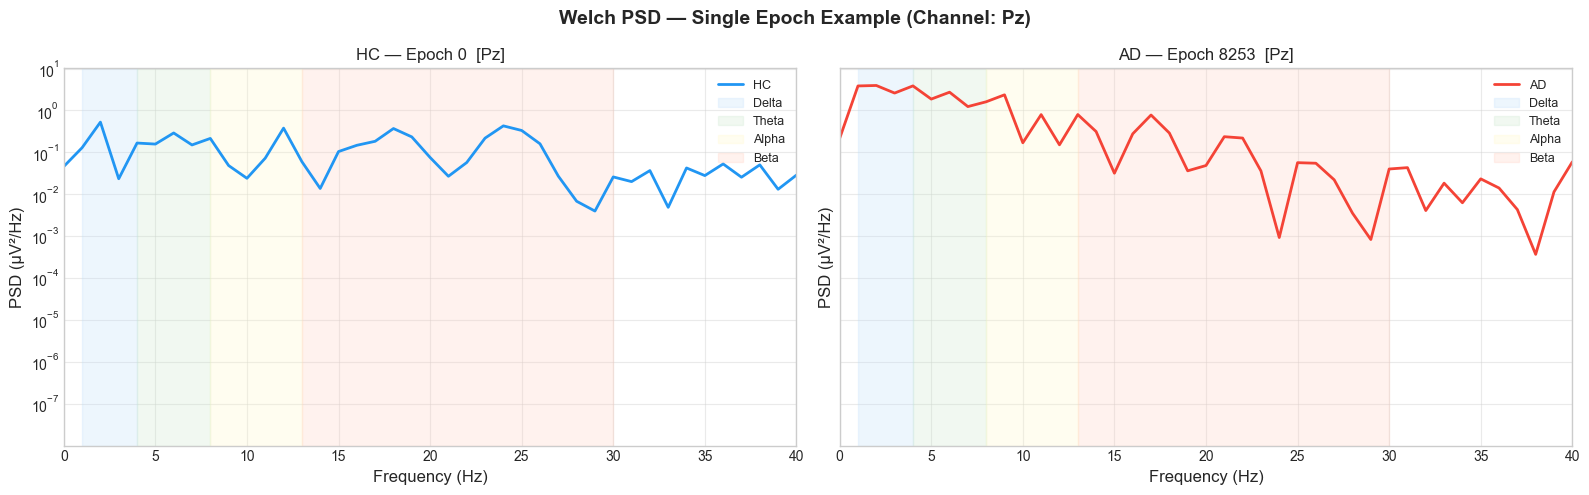

Figure saved → figures/psd_single_epoch_example.png


In [12]:
# Pick one representative epoch from each group
hc_idx = np.where(labels == 0.0)[0][0]
ad_idx = np.where(labels == 1.0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle('Welch PSD — Single Epoch Example (Channel: Pz)', fontsize=14, fontweight='bold')

pz_ch = CHANNEL_NAMES.index('Pz')    # index 18

for ax, idx, group in zip(axes, [hc_idx, ad_idx], ['HC', 'AD']):
    epoch = X[idx]
    freqs_e, psds_e = compute_psd_all_channels(epoch, FS)
    
    ax.semilogy(freqs_e, psds_e[pz_ch], color=GROUP_COLORS[group], lw=2, label=group)
    
    # Shade frequency bands
    band_colors = ['#bbdefb', '#c8e6c9', '#fff9c4', '#ffccbc']
    for (band_name, (lo, hi)), bc in zip(BANDS.items(), band_colors):
        ax.axvspan(lo, hi, alpha=0.25, color=bc, label=band_name)
    
    ax.set_xlim(0, 40)
    ax.set_xlabel('Frequency (Hz)', fontsize=12)
    ax.set_ylabel('PSD (µV²/Hz)', fontsize=12)
    ax.set_title(f'{group} — Epoch {idx}  [{CHANNEL_NAMES[pz_ch]}]', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('figures/psd_single_epoch_example.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/psd_single_epoch_example.png")

## 5. Full Feature Extraction

For every subject we:
1. Aggregate all epochs belonging to that subject
2. For each channel, compute band power on every epoch
3. Average across epochs to get a stable per-subject, per-channel, per-band feature

> **Note:** Computing Welch on all ~102 k epochs × 19 channels may take a few minutes.

In [14]:
# ── Pre-allocate results storage ─────────────────────────────────────────────
unique_subjects = np.unique(global_sub_ids)
n_channels  = len(CHANNEL_NAMES)
band_names  = list(BANDS.keys())    # ['Delta', 'Theta', 'Alpha', 'Beta']
n_bands     = len(band_names)

# subject_features and subject_groups are built dynamically (skipping unknown labels)
subject_features_list = []
subject_groups        = []    # 'HC', 'AD', or 'FTD'
subject_ids_valid     = []

skipped = 0
print(f"Scanning {len(unique_subjects)} subjects (unknown labels will be skipped) ...")
print("(This may take 3-8 minutes depending on hardware)\n")

for s_idx, sub_id in enumerate(unique_subjects):
    # All epochs for this subject
    mask      = global_sub_ids == sub_id
    sub_X     = X[mask]                      # (n_epochs_sub, 128, 19)
    sub_label = labels[mask][0]              # same label for all epochs

    # Skip subjects whose label is not in GROUP_LABELS
    if sub_label not in GROUP_LABELS:
        skipped += 1
        continue

    subject_groups.append(GROUP_LABELS[sub_label])
    subject_ids_valid.append(sub_id)

    # Per-epoch, per-channel band power -> average over epochs
    epoch_powers = np.zeros((len(sub_X), n_channels, n_bands))
    for e_idx, epoch in enumerate(sub_X):
        for ch_idx in range(n_channels):
            for b_idx, (band_name, band_range) in enumerate(BANDS.items()):
                epoch_powers[e_idx, ch_idx, b_idx] = compute_band_power(
                    epoch[:, ch_idx], FS, band_range
                )

    subject_features_list.append(epoch_powers.mean(axis=0))   # mean over epochs

    done = len(subject_features_list)
    if done % 20 == 0 or done == len(unique_subjects):
        print(f"  [{done}] {sub_id} ({subject_groups[-1]}) - done")

subject_features = np.array(subject_features_list)   # (n_valid, n_channels, n_bands)
subject_groups   = np.array(subject_groups)
n_subjects       = len(subject_features)
print(f"\n✅ Feature extraction complete.")
print(f"   Valid subjects : {n_subjects}  (skipped {skipped} with unknown labels)")
print(f"   subject_features shape: {subject_features.shape}")
for grp in np.unique(subject_groups):
    print(f"   {grp} subjects: {np.sum(subject_groups == grp)}")

Scanning 241 subjects (unknown labels will be skipped) ...
(This may take 3-8 minutes depending on hardware)

  [20] AD-Auditory_30 (FTD) - done
  [40] ADFSU_24 (AD) - done
  [60] ADFSU_44 (AD) - done
  [80] ADFSU_64 (AD) - done
  [100] ADFSU_84 (HC) - done
  [120] ADFTD_21 (FTD) - done
  [140] ADFTD_41 (HC) - done
  [160] ADFTD_61 (HC) - done
  [180] ADFTD_81 (AD) - done
  [200] ADSZ_22 (AD) - done
  [220] ADSZ_42 (HC) - done
  [240] APAVA-19_23.0 (HC) - done

✅ Feature extraction complete.
   Valid subjects : 240  (skipped 1 with unknown labels)
   subject_features shape: (240, 19, 4)
   AD subjects: 122
   FTD subjects: 40
   HC subjects: 78


## 6. Channel × Band Power Table

Build a **flat table** where each row is one subject-channel combination, and columns are the four band powers plus group label. Then aggregate to mean per channel per group.

In [16]:
# ── Build flat per-subject-per-channel DataFrame ─────────────────────────────
rows = []
for s_idx, sub_id in enumerate(subject_ids_valid):
    group = subject_groups[s_idx]
    for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
        row = {
            'Subject': sub_id,
            'Group':   group,
            'Channel': ch_name,
        }
        for b_idx, band_name in enumerate(band_names):
            row[f'{band_name}_Power'] = subject_features[s_idx, ch_idx, b_idx]
        rows.append(row)

df_features = pd.DataFrame(rows)
print(f"Full feature table shape: {df_features.shape}")
print(f"Columns: {list(df_features.columns)}")
df_features.head(10)

Full feature table shape: (4560, 7)
Columns: ['Subject', 'Group', 'Channel', 'Delta_Power', 'Theta_Power', 'Alpha_Power', 'Beta_Power']


,Subject,Group,Channel,Delta_Power,Theta_Power,Alpha_Power,Beta_Power
0,AD-Auditory_10,HC,Fp1,21.597821,7.696976,2.337172,4.521619
1,AD-Auditory_10,HC,Fp2,25.253020,6.222819,3.048621,22.842925
2,AD-Auditory_10,HC,F3,18.765192,4.836275,3.954630,19.090943
3,AD-Auditory_10,HC,F4,20.188954,2.726951,1.440119,7.190733
4,AD-Auditory_10,HC,C3,5.013311,1.786520,0.905214,2.624498
5,AD-Auditory_10,HC,C4,6.684111,1.971155,2.246232,33.304051
6,AD-Auditory_10,HC,P3,10.346136,2.876187,2.693069,14.037368
7,AD-Auditory_10,HC,P4,4.929800,1.981966,2.460493,2.850756
8,AD-Auditory_10,HC,O1,1.364566,0.529350,0.682191,2.749893
9,AD-Auditory_10,HC,O2,1.438053,0.599133,0.528422,1.749856


In [17]:
# ── Summary table: mean band power per Channel, per Group ────────────────────
summary = (
    df_features
    .groupby(['Channel', 'Group'])[['Delta_Power', 'Theta_Power', 'Alpha_Power', 'Beta_Power']]
    .mean()
    .reset_index()
)

# Pivot so AD and HC appear side by side for each channel
pivot = summary.pivot(index='Channel', columns='Group',
                      values=['Alpha_Power', 'Theta_Power', 'Delta_Power', 'Beta_Power'])
pivot.columns = [f'{band.split("_")[0]}_{grp}' for band, grp in pivot.columns]
pivot = pivot.reset_index()

# Reorder columns: Channel | Alpha_AD | Alpha_HC | Theta_AD | Theta_HC | Delta_AD | Delta_HC
col_order = ['Channel'] + sorted(
    [c for c in pivot.columns if c != 'Channel'],
    key=lambda x: (x.split('_')[0], x.split('_')[1])
)
pivot = pivot[col_order]

print("\n" + "="*90)
print("  MEAN BAND POWER PER CHANNEL (µV²/Hz)   |   AD = Alzheimer's   HC = Healthy Control")
print("="*90)
print(pivot.to_string(index=False, float_format='{:.6f}'.format))
print("="*90)


  MEAN BAND POWER PER CHANNEL (µV²/Hz)   |   AD = Alzheimer's   HC = Healthy Control
Channel  Alpha_AD  Alpha_FTD  Alpha_HC   Beta_AD  Beta_FTD   Beta_HC  Delta_AD  Delta_FTD  Delta_HC  Theta_AD  Theta_FTD  Theta_HC
     C3 11.945106   1.748016  6.288413  6.540260  2.572845  4.603353 22.704601   1.812341 12.539104 24.919772   2.530185  7.208360
     C4 11.025231   1.747138  5.883064  9.549880  2.539829  5.550712 23.056069   1.614186 11.546941 22.593470   2.383695  6.112711
     Cz 12.278290   2.937197 41.725398  5.821095  2.102766 10.366704 19.743777   3.253926 14.435225 15.670493   3.507569  8.323649
     F3  6.209698   1.575922  3.414865  6.543591  3.076170  5.750713 19.996219   1.776306 10.263923 13.878021   2.289872  4.036565
     F4 10.299281   1.594457  5.215964  9.235294  2.740425  4.587095 19.420419   1.485468 12.336058 20.627848   2.216395  6.379624
     F7 12.402130   1.879519  9.866397  7.936311  1.956995  8.838403 15.610296   1.068066 12.870489 19.975920   1.719353  7.0266

In [18]:
# ── Nicely formatted Channel | Alpha Power | Theta Power | Delta Power table ─
# (as requested — showing AD values, then HC values in separate sections)

for group in ['AD', 'HC']:
    g_df = df_features[df_features['Group'] == group]
    tbl = (
        g_df.groupby('Channel')[['Alpha_Power', 'Theta_Power', 'Delta_Power', 'Beta_Power']]
            .mean()
            .reset_index()
    )
    # Sort channels alphabetically
    tbl = tbl.sort_values('Channel').reset_index(drop=True)
    tbl.columns = ['Channel', 'Alpha Power (µV²/Hz)', 'Theta Power (µV²/Hz)',
                   'Delta Power (µV²/Hz)', 'Beta Power (µV²/Hz)']
    label = "Alzheimer's Disease (AD)" if group == 'AD' else 'Healthy Control (HC)'
    print(f"\n{'='*80}")
    print(f"  {label}")
    print(f"{'='*80}")
    print(tbl.to_string(index=False, float_format='{:.6f}'.format))

# Save the full table to CSV
df_features.to_csv('eeg_band_power_features.csv', index=False)
print("\n✅ Full feature table saved → eeg_band_power_features.csv")


  Alzheimer's Disease (AD)
Channel  Alpha Power (µV²/Hz)  Theta Power (µV²/Hz)  Delta Power (µV²/Hz)  Beta Power (µV²/Hz)
     C3             11.945106             24.919772             22.704601             6.540260
     C4             11.025231             22.593470             23.056069             9.549880
     Cz             12.278290             15.670493             19.743777             5.821095
     F3              6.209698             13.878021             19.996219             6.543591
     F4             10.299281             20.627848             19.420419             9.235294
     F7             12.402130             19.975920             15.610296             7.936311
     F8              6.752618             10.853743             10.384918            14.061301
    Fp1              7.879893             22.066909             50.769216             9.632494
    Fp2              8.079175             22.605036             52.186857             8.439877
     Fz              9

## 7. Statistical Comparison: AD vs HC

We use an **independent-samples t-test** (Welch's t-test, unequal variances) to compare each band's power at each channel between groups.

In [19]:
stat_rows = []
for ch_name in CHANNEL_NAMES:
    for band_name in band_names:
        col = f'{band_name}_Power'
        ad_vals = df_features[(df_features['Group']=='AD') & (df_features['Channel']==ch_name)][col].values
        hc_vals = df_features[(df_features['Group']=='HC') & (df_features['Channel']==ch_name)][col].values
        t_stat, p_val = stats.ttest_ind(ad_vals, hc_vals, equal_var=False)
        stat_rows.append({
            'Channel':  ch_name,
            'Band':     band_name,
            'AD_mean':  ad_vals.mean(),
            'HC_mean':  hc_vals.mean(),
            'Diff (AD-HC)': ad_vals.mean() - hc_vals.mean(),
            't_stat':   t_stat,
            'p_value':  p_val,
            'significant (p<.05)': p_val < 0.05,
        })

df_stats = pd.DataFrame(stat_rows)

# Show the most significantly different channel-band pairs
sig = df_stats[df_stats['significant (p<.05)']].sort_values('p_value')
print(f"Statistically significant (p < 0.05) channel-band pairs: {len(sig)} / {len(df_stats)}\n")
print(sig.to_string(index=False, float_format='{:.4f}'.format))

Statistically significant (p < 0.05) channel-band pairs: 46 / 76

Channel  Band  AD_mean  HC_mean  Diff (AD-HC)  t_stat  p_value  significant (p<.05)
     P3 Theta  14.0768   3.8164       10.2605  7.5634   0.0000                 True
     C3 Theta  24.9198   7.2084       17.7114  7.4792   0.0000                 True
     C4 Theta  22.5935   6.1127       16.4808  7.3880   0.0000                 True
     F3 Theta  13.8780   4.0366        9.8415  7.1079   0.0000                 True
     F4 Theta  20.6278   6.3796       14.2482  7.0292   0.0000                 True
    Fp1  Beta   9.6325   3.0148        6.6177  6.6667   0.0000                 True
     F7 Theta  19.9759   7.0267       12.9492  6.3971   0.0000                 True
     O2 Theta  23.5237   8.6898       14.8339  5.9942   0.0000                 True
     T6 Theta  22.4067   8.1752       14.2314  5.9320   0.0000                 True
     T4 Theta  21.5491   7.9148       13.6344  5.8527   0.0000                 True
     F8 Th

## 8. Visualisations

### 8a. Grand-Average PSD: AD vs HC (all channels)

Computing grand-average PSD (all channels combined) …


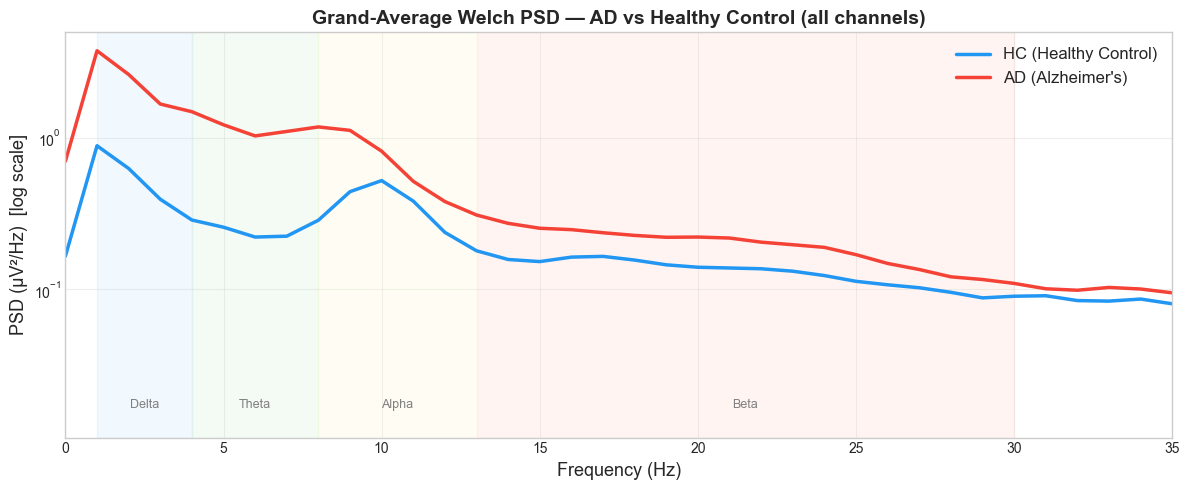

Figure saved → figures/grand_avg_psd_ad_vs_hc.png


In [20]:
os.makedirs('figures', exist_ok=True)

# Compute mean PSD across ALL epochs for each group
print("Computing grand-average PSD (all channels combined) …")

hc_mask = labels == 0.0
ad_mask = labels == 1.0

# Use a random subsample of 2000 epochs per group for speed
rng = np.random.default_rng(42)
hc_sample_idx = rng.choice(np.where(hc_mask)[0], size=min(2000, hc_mask.sum()), replace=False)
ad_sample_idx = rng.choice(np.where(ad_mask)[0], size=min(2000, ad_mask.sum()), replace=False)

def mean_psd_over_epochs(epoch_indices, channel_idx):
    psds_list = []
    for idx in epoch_indices:
        f, p = welch(X[idx, :, channel_idx], fs=FS,
                     nperseg=EPOCH_LEN, window='hann',
                     noverlap=EPOCH_LEN//2, scaling='density')
        psds_list.append(p)
    return f, np.mean(psds_list, axis=0)

# Grand average across all 19 channels
hc_grand, ad_grand = [], []
for ch in range(n_channels):
    f_hc, p_hc = mean_psd_over_epochs(hc_sample_idx, ch)
    f_ad, p_ad = mean_psd_over_epochs(ad_sample_idx, ch)
    hc_grand.append(p_hc)
    ad_grand.append(p_ad)

hc_grand_mean = np.mean(hc_grand, axis=0)
ad_grand_mean = np.mean(ad_grand, axis=0)
freqs_plot    = f_hc   # same for all

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs_plot, hc_grand_mean, color=GROUP_COLORS['HC'], lw=2.5, label='HC (Healthy Control)')
ax.semilogy(freqs_plot, ad_grand_mean, color=GROUP_COLORS['AD'], lw=2.5, label="AD (Alzheimer's)")

band_colors_fill = ['#bbdefb', '#c8e6c9', '#fff9c4', '#ffccbc']
for (band_name, (lo, hi)), bc in zip(BANDS.items(), band_colors_fill):
    ax.axvspan(lo, hi, alpha=0.20, color=bc)
    ax.text((lo+hi)/2, ax.get_ylim()[0]*1.5, band_name,
            ha='center', va='bottom', fontsize=9, color='gray')

ax.set_xlim(0, 35)
ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel('PSD (µV²/Hz)  [log scale]', fontsize=13)
ax.set_title('Grand-Average Welch PSD — AD vs Healthy Control (all channels)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('figures/grand_avg_psd_ad_vs_hc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/grand_avg_psd_ad_vs_hc.png")

### 8b. Band Power Comparison: Bar Plots per Band

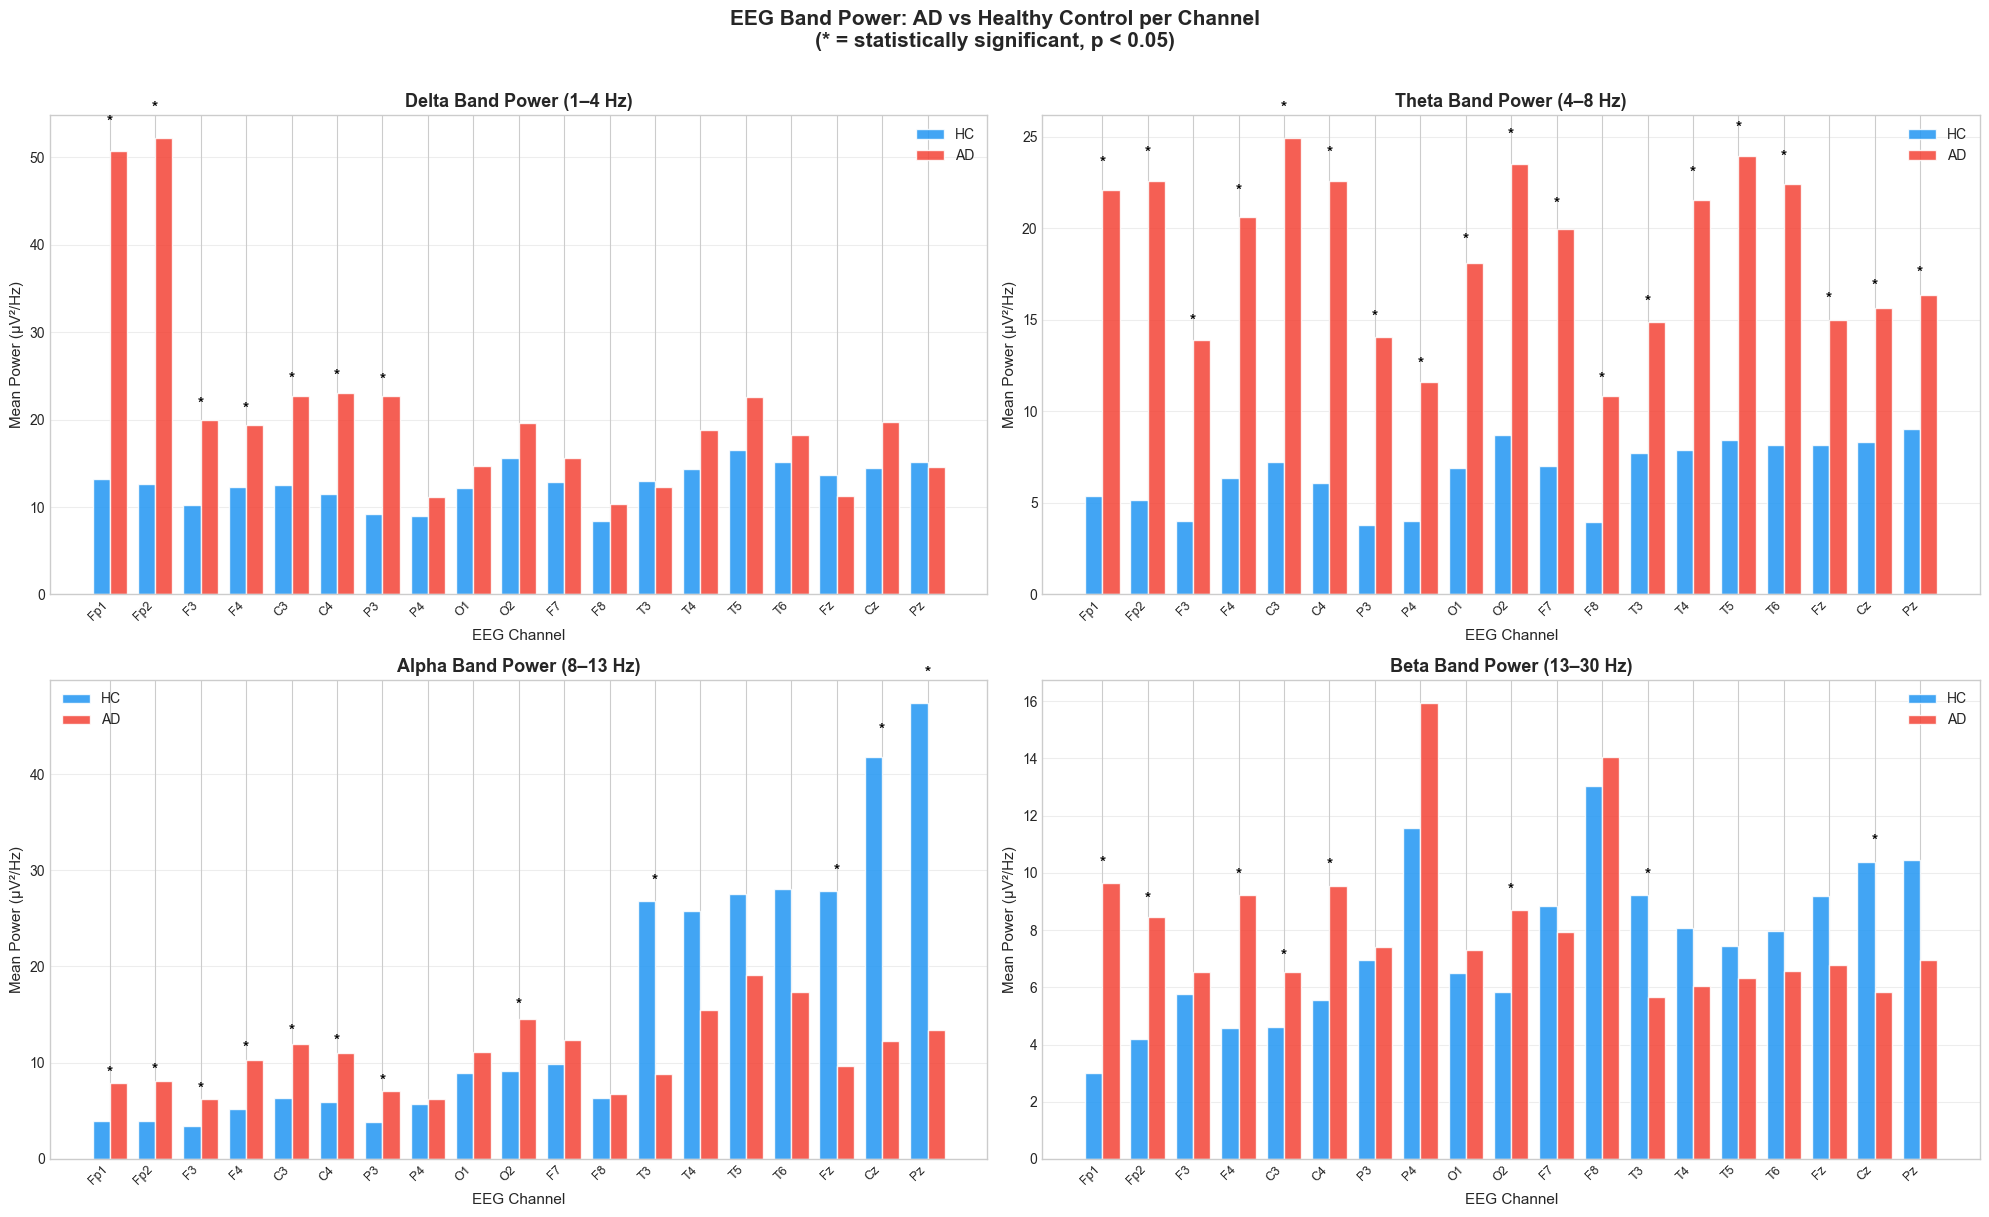

Figure saved → figures/band_power_bar_all_channels.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, band_name in zip(axes, band_names):
    col = f'{band_name}_Power'
    
    # Mean per channel per group
    grouped = (
        df_features.groupby(['Channel', 'Group'])[col]
        .mean().reset_index()
        .pivot(index='Channel', columns='Group', values=col)
        .reindex(CHANNEL_NAMES)      # preserve 10-20 order
    )
    
    x = np.arange(len(CHANNEL_NAMES))
    width = 0.38
    
    bars_hc = ax.bar(x - width/2, grouped['HC'], width, label='HC',
                     color=GROUP_COLORS['HC'], alpha=0.85, edgecolor='white')
    bars_ad = ax.bar(x + width/2, grouped['AD'], width, label='AD',
                     color=GROUP_COLORS['AD'], alpha=0.85, edgecolor='white')
    
    # Mark statistically significant channels with *
    for ch_idx, ch in enumerate(CHANNEL_NAMES):
        row = df_stats[(df_stats['Channel']==ch) & (df_stats['Band']==band_name)]
        if not row.empty and row['significant (p<.05)'].values[0]:
            ymax = max(grouped.loc[ch, 'HC'], grouped.loc[ch, 'AD'])
            ax.text(ch_idx, ymax * 1.05, '*', ha='center', va='bottom',
                    fontsize=11, color='black', fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('EEG Channel', fontsize=11)
    ax.set_ylabel('Mean Power (µV²/Hz)', fontsize=11)
    ax.set_title(f'{band_name} Band Power ({BANDS[band_name][0]}–{BANDS[band_name][1]} Hz)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.35)

fig.suptitle('EEG Band Power: AD vs Healthy Control per Channel\n'
             '(* = statistically significant, p < 0.05)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/band_power_bar_all_channels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/band_power_bar_all_channels.png")

### 8c. Box Plots — Distribution of Band Power Across Subjects

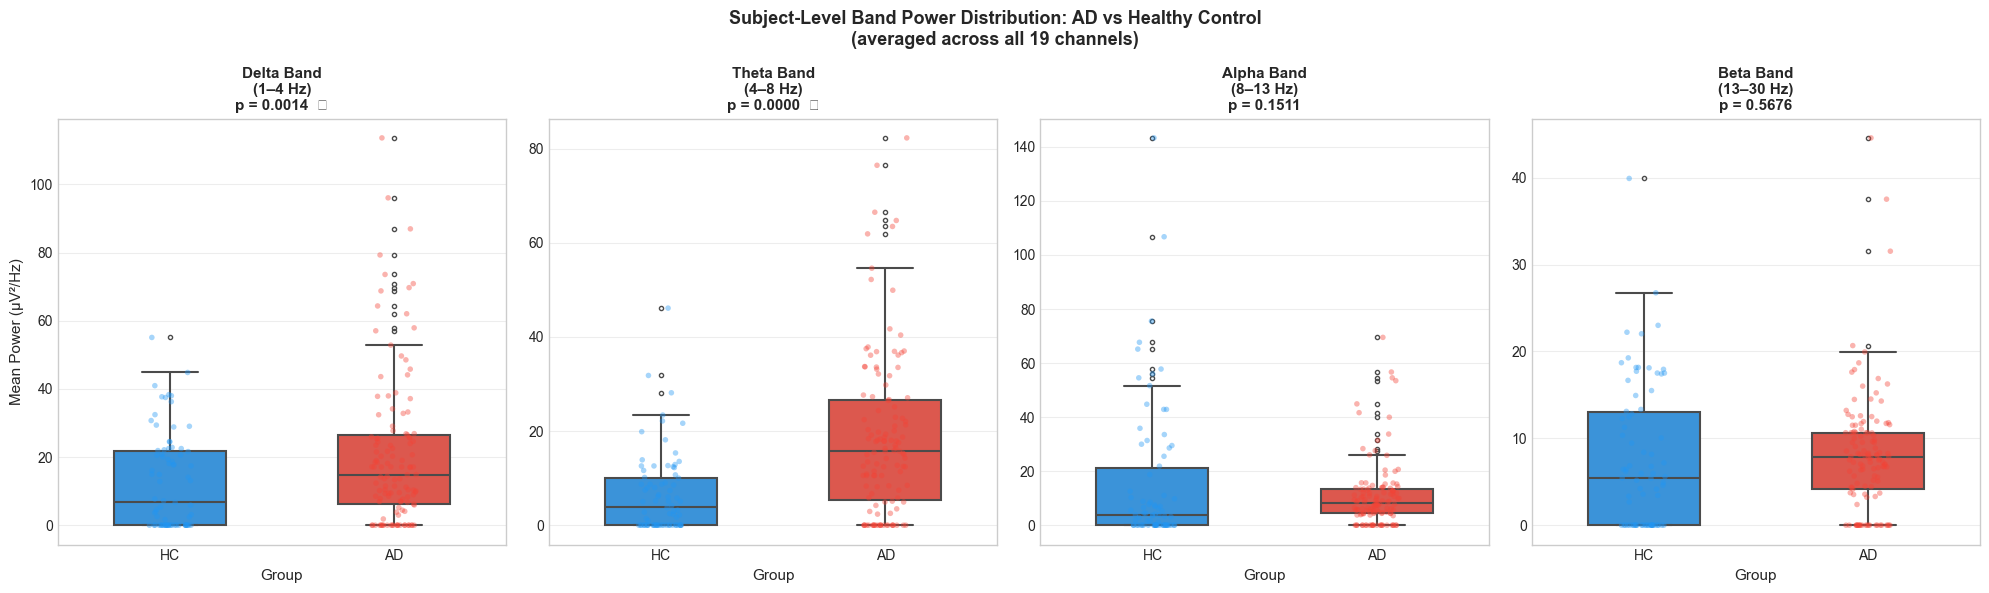

Figure saved → figures/band_power_boxplot_subjects.png


In [22]:
# Aggregate to subject level (mean across channels) for clean box plots
df_subject_level = (
    df_features.groupby(['Subject', 'Group'])
    [['Delta_Power', 'Theta_Power', 'Alpha_Power', 'Beta_Power']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, band_name in zip(axes, band_names):
    col = f'{band_name}_Power'
    sns.boxplot(
        data=df_subject_level, x='Group', y=col,
        palette=GROUP_COLORS, order=['HC', 'AD'],
        width=0.5, linewidth=1.5, fliersize=3, ax=ax
    )
    sns.stripplot(
        data=df_subject_level, x='Group', y=col,
        palette=GROUP_COLORS, order=['HC', 'AD'],
        size=4, alpha=0.4, jitter=True, ax=ax
    )
    
    # Annotate with t-test p-value (pooled across channels)
    ad_v = df_subject_level[df_subject_level['Group']=='AD'][col].values
    hc_v = df_subject_level[df_subject_level['Group']=='HC'][col].values
    _, pv = stats.ttest_ind(ad_v, hc_v, equal_var=False)
    sig_str = f'p = {pv:.4f}' + ('  ✓' if pv < 0.05 else '')
    ax.set_title(f'{band_name} Band\n({BANDS[band_name][0]}–{BANDS[band_name][1]} Hz)\n{sig_str}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Group', fontsize=11)
    ax.set_ylabel('Mean Power (µV²/Hz)' if ax == axes[0] else '', fontsize=11)
    ax.grid(axis='y', alpha=0.35)

fig.suptitle('Subject-Level Band Power Distribution: AD vs Healthy Control\n'
             '(averaged across all 19 channels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/band_power_boxplot_subjects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/band_power_boxplot_subjects.png")

### 8d. Heatmap — Mean Band Power by Channel and Group

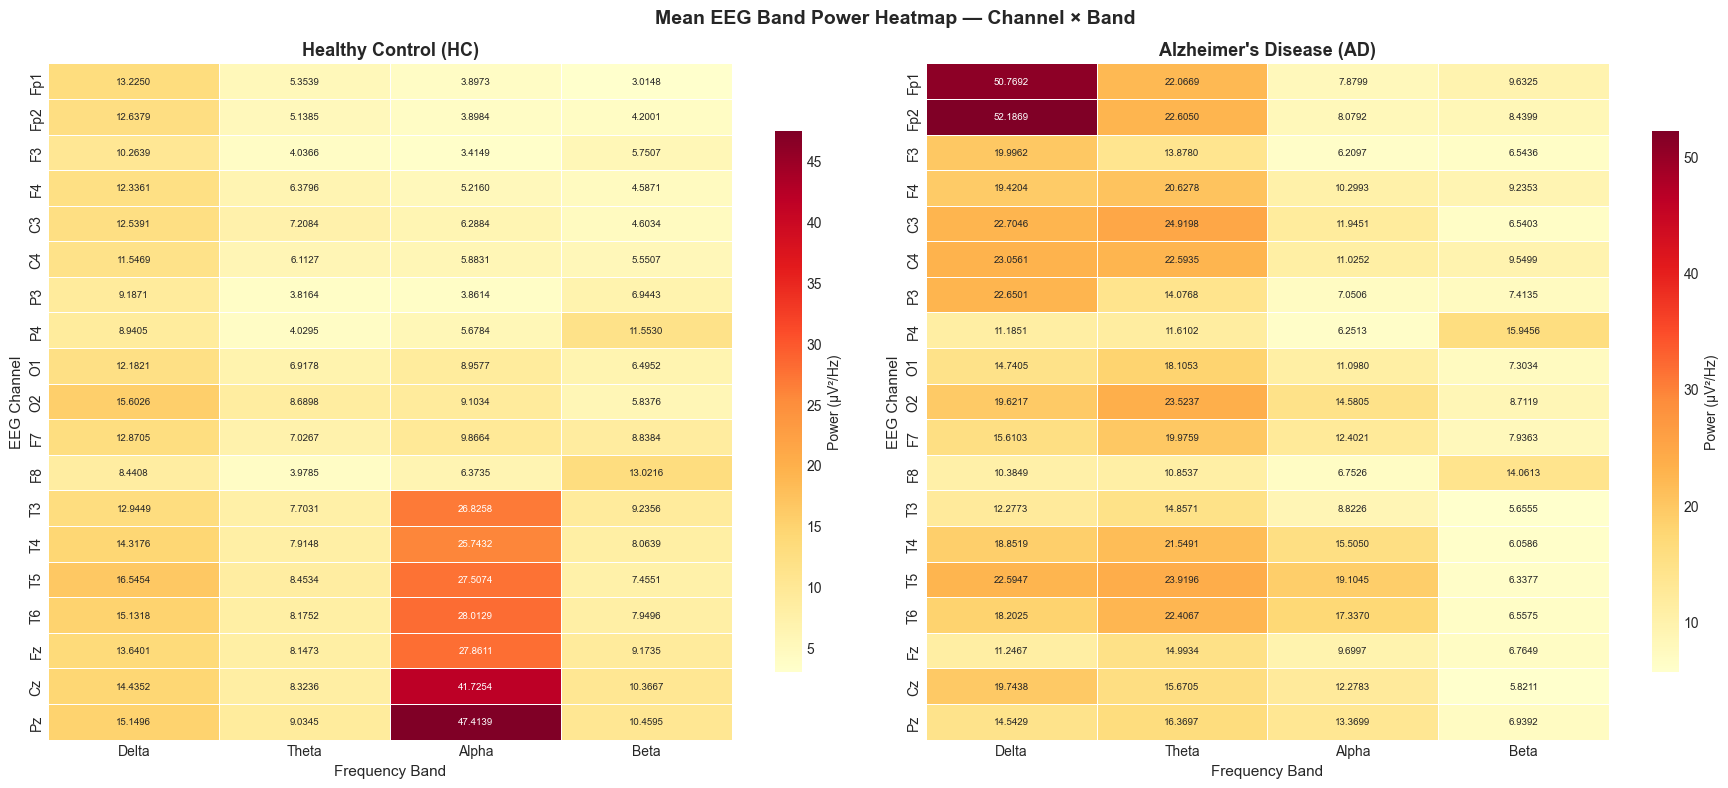

Figure saved → figures/band_power_heatmap.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, group in zip(axes, ['HC', 'AD']):
    g_df = df_features[df_features['Group'] == group]
    heatmap_data = (
        g_df.groupby('Channel')[['Delta_Power', 'Theta_Power', 'Alpha_Power', 'Beta_Power']]
        .mean()
        .reindex(CHANNEL_NAMES)
    )
    heatmap_data.columns = ['Delta', 'Theta', 'Alpha', 'Beta']
    
    sns.heatmap(
        heatmap_data, ax=ax,
        cmap='YlOrRd', annot=True, fmt='.4f',
        annot_kws={'size': 7}, linewidths=0.5,
        cbar_kws={'label': 'Power (µV²/Hz)', 'shrink': 0.8}
    )
    grp_label = "Alzheimer's Disease (AD)" if group == 'AD' else 'Healthy Control (HC)'
    ax.set_title(grp_label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency Band', fontsize=11)
    ax.set_ylabel('EEG Channel', fontsize=11)

fig.suptitle('Mean EEG Band Power Heatmap — Channel × Band', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/band_power_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/band_power_heatmap.png")

### 8e. Difference Heatmap — (AD − HC) Relative Change

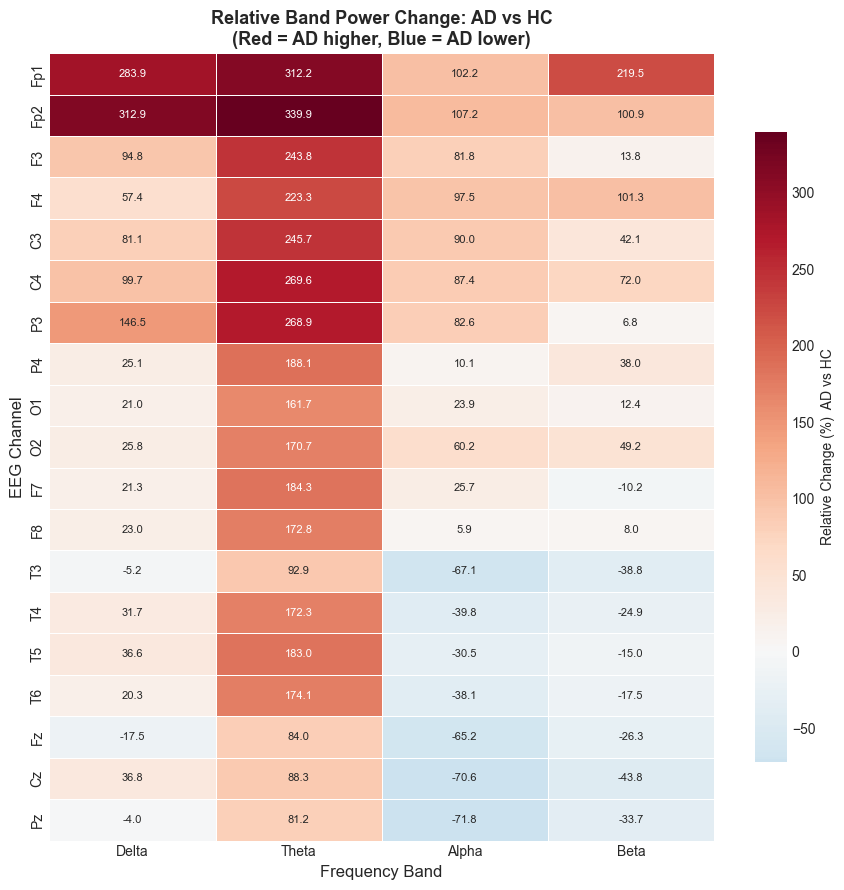

Figure saved → figures/band_power_relative_diff_heatmap.png


In [24]:
hc_means = (
    df_features[df_features['Group']=='HC']
    .groupby('Channel')[['Delta_Power','Theta_Power','Alpha_Power','Beta_Power']]
    .mean().reindex(CHANNEL_NAMES)
)
ad_means = (
    df_features[df_features['Group']=='AD']
    .groupby('Channel')[['Delta_Power','Theta_Power','Alpha_Power','Beta_Power']]
    .mean().reindex(CHANNEL_NAMES)
)

# Relative difference: (AD - HC) / HC  × 100  [percent]
rel_diff = ((ad_means - hc_means) / hc_means * 100)
rel_diff.columns = ['Delta', 'Theta', 'Alpha', 'Beta']

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(
    rel_diff, ax=ax,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Relative Change (%)  AD vs HC', 'shrink': 0.8}
)
ax.set_title('Relative Band Power Change: AD vs HC\n'
             '(Red = AD higher, Blue = AD lower)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency Band', fontsize=12)
ax.set_ylabel('EEG Channel', fontsize=12)
plt.tight_layout()
plt.savefig('figures/band_power_relative_diff_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/band_power_relative_diff_heatmap.png")

## 9. Key Findings Summary

Print a concise clinical-style summary of the band power differences.

In [25]:
# Global (across all channels) mean per band per group
global_means = (
    df_subject_level
    .groupby('Group')[['Delta_Power','Theta_Power','Alpha_Power','Beta_Power']]
    .mean()
)

print("="*70)
print("  KEY FINDINGS — EEG FREQUENCY BAND POWER: AD vs HC")
print("="*70)
print(f"  {'Band':<10} {'HC Mean (µV²/Hz)':>20} {'AD Mean (µV²/Hz)':>20} {'Change':>12}")
print("-"*70)

for band_name in band_names:
    col    = f'{band_name}_Power'
    hc_val = global_means.loc['HC', col]
    ad_val = global_means.loc['AD', col]
    pct    = (ad_val - hc_val) / hc_val * 100
    arrow  = '↑' if pct > 0 else '↓'
    print(f"  {band_name:<10} {hc_val:>20.6f} {ad_val:>20.6f} {arrow}{abs(pct):>9.1f}%")

print("="*70)
print()
print("Literature-expected patterns in Alzheimer's Disease:")
print("  • Delta  ↑  (increased slow-wave activity)")
print("  • Theta  ↑  (increased slow-wave activity)")
print("  • Alpha  ↓  (decreased posterior alpha — hallmark of AD)")
print("  • Beta   ↓  (decreased fast activity)")
print()
print("Top statistically significant channel-band pairs (p < 0.05):")
top = df_stats[df_stats['significant (p<.05)']].sort_values('p_value').head(10)
for _, row in top.iterrows():
    direction = 'AD↑' if row['Diff (AD-HC)'] > 0 else 'AD↓'
    print(f"  {row['Channel']:>4s} — {row['Band']:<6s}  p={row['p_value']:.4f}  {direction}")
print("="*70)

  KEY FINDINGS — EEG FREQUENCY BAND POWER: AD vs HC
  Band           HC Mean (µV²/Hz)     AD Mean (µV²/Hz)       Change
----------------------------------------------------------------------
  Delta                 12.733536            21.041361 ↑     65.2%
  Theta                  6.654747            18.663308 ↑    180.5%
  Alpha                 15.659391            11.036339 ↓     29.5%
  Beta                   7.531619             8.181475 ↑      8.6%

Literature-expected patterns in Alzheimer's Disease:
  • Delta  ↑  (increased slow-wave activity)
  • Theta  ↑  (increased slow-wave activity)
  • Alpha  ↓  (decreased posterior alpha — hallmark of AD)
  • Beta   ↓  (decreased fast activity)

Top statistically significant channel-band pairs (p < 0.05):
    P3 — Theta   p=0.0000  AD↑
    C3 — Theta   p=0.0000  AD↑
    C4 — Theta   p=0.0000  AD↑
    F3 — Theta   p=0.0000  AD↑
    F4 — Theta   p=0.0000  AD↑
   Fp1 — Beta    p=0.0000  AD↑
    F7 — Theta   p=0.0000  AD↑
    O2 — Theta   p=

## 10. Save Results

All outputs are saved to disk for downstream use (e.g. machine learning).

In [26]:
# Save per-subject band power features (subject-level, per channel)
df_features.to_csv('eeg_band_power_features.csv', index=False)

# Save subject-level aggregated features (mean across channels)
df_subject_level.to_csv('eeg_band_power_subject_level.csv', index=False)

# Save statistical test results
df_stats.to_csv('eeg_band_power_stats.csv', index=False)

# Save the numpy feature array for ML
np.save('eeg_subject_features.npy', subject_features)   # (241, 19, 4)
np.save('eeg_subject_groups.npy', subject_groups)        # (241,) → 'HC'/'AD'

print("✅ All results saved:")
print("   eeg_band_power_features.csv      — per-subject per-channel features")
print("   eeg_band_power_subject_level.csv — per-subject (mean across channels)")
print("   eeg_band_power_stats.csv         — t-test statistics")
print("   eeg_subject_features.npy         — numpy array (241 × 19 × 4)")
print("   eeg_subject_groups.npy           — numpy array (241,)")
print("   figures/                         — all visualisation plots")

print("\n📊 Feature matrix shape:", subject_features.shape,
      " → (subjects × channels × bands)")

✅ All results saved:
   eeg_band_power_features.csv      — per-subject per-channel features
   eeg_band_power_subject_level.csv — per-subject (mean across channels)
   eeg_band_power_stats.csv         — t-test statistics
   eeg_subject_features.npy         — numpy array (241 × 19 × 4)
   eeg_subject_groups.npy           — numpy array (241,)
   figures/                         — all visualisation plots

📊 Feature matrix shape: (240, 19, 4)  → (subjects × channels × bands)
